# House MD — Metin Sınıflandırma Projesi
**Görev:** Tüm özellik sütunlarını kullanarak `correct_prediction` (hastalık adı) tahmin etmek

## Adım 1 — Ortam Kurulumu

In [154]:
%pip install pandas scikit-learn matplotlib seaborn scipy snowballstemmer gensim lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, warnings
warnings.filterwarnings('ignore')

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## Adım 2 — Veri Yükleme ve EDA

In [60]:
df = pd.read_csv('Last_HouseMD_DataSet(Sayfa1).csv', sep=';', encoding='utf-8-sig')
print('Satır sayısı :', len(df))
print('Sütunlar     :', df.columns.tolist())
df.head(3)

Satır sayısı : 7282
Sütunlar     : ['season', 'episode', 'speaker', 'Symptom', 'Test', 'Drug', 'Procedure', 'Intent', 'diagnosis_stage', 'Sarcasm', 'Emotion', 'Organ', 'correct_prediction', 'model_prediction', 'text', 'medical_entities']


,season,episode,speaker,Symptom,Test,Drug,Procedure,Intent,diagnosis_stage,Sarcasm,Emotion,Organ,correct_prediction,model_prediction,text,medical_entities
0,1,1,Wilson,nöbet,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,29 yaşında bir kadın hasta; ilk nöbetini bir a...,"[{""text"": ""nöbet"", ""type"": ""Symptom""}]"
1,1,1,Wilson,afazi,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,"Konuşma yetisini kaybetmiş, bebek gibi anlamsı...","[{""text"": ""afazi"", ""type"": ""Symptom""}]"
2,1,1,Wilson,zihinsel durum bozukluğu,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,Mental durumu giderek kötüleşiyor.,"[{""text"": ""zihinsel durum bozukluğu"", ""type"": ..."


In [61]:
TIBBI_SUTUNLAR = ['Symptom', 'Test', 'Drug', 'Procedure', 'Organ']
df[TIBBI_SUTUNLAR] = df[TIBBI_SUTUNLAR].fillna('bilgi_yok')

print('Tıbbi sütunlardaki NaN → "bilgi_yok" ile dolduruldu')
df[TIBBI_SUTUNLAR].head(10)

Tıbbi sütunlardaki NaN → "bilgi_yok" ile dolduruldu


,Symptom,Test,Drug,Procedure,Organ
0,nöbet,bilgi_yok,bilgi_yok,bilgi_yok,beyin
1,afazi,bilgi_yok,bilgi_yok,bilgi_yok,beyin
2,zihinsel durum bozukluğu,bilgi_yok,bilgi_yok,bilgi_yok,beyin
3,bilgi_yok,bilgi_yok,bilgi_yok,bilgi_yok,beyin
4,bilgi_yok,bilgi_yok,bilgi_yok,bilgi_yok,beyin
5,bilgi_yok,protein belirteçleri,bilgi_yok,bilgi_yok,beyin
6,bilgi_yok,bilgi_yok,bilgi_yok,radyasyon tedavisi,beyin
7,lezyon,MR,bilgi_yok,bilgi_yok,beyin
8,bilgi_yok,bilgi_yok,bilgi_yok,bilgi_yok,beyin
9,bilgi_yok,BT,bilgi_yok,bilgi_yok,beyin


In [62]:
bos = df.isnull().sum().sort_values(ascending=False)
pd.DataFrame({'Boş Sayısı': bos, 'Boş %': (bos / len(df) * 100).round(1)})

,Boş Sayısı,Boş %
model_prediction,5874,80.7
correct_prediction,1470,20.2
Intent,200,2.7
medical_entities,139,1.9
Emotion,2,0.0
diagnosis_stage,1,0.0
text,1,0.0
season,0,0.0
Procedure,0,0.0
Drug,0,0.0


In [63]:
# correct_prediction'daki NaN satırlar çıkarılıyor.
# Bu satırlarda hedef etiket yok; etiket olmadan denetimli öğrenme mümkün değil.
null_hedef = df['correct_prediction'].isnull().sum()
print(f'correct_prediction — boş satır (çıkarılıyor): {null_hedef} ({null_hedef/len(df)*100:.1f}%)')
df = df[df['correct_prediction'].notna()].copy()

print(f'\nKalan satır sayısı: {len(df)}')
print('\n── Güncel boş değer tablosu ──')
bos2 = df.isnull().sum().sort_values(ascending=False)
pd.DataFrame({'Boş Sayısı': bos2, 'Boş %': (bos2 / len(df) * 100).round(1)})

correct_prediction — boş satır (çıkarılıyor): 1470 (20.2%)

Kalan satır sayısı: 5812

── Güncel boş değer tablosu ──


,Boş Sayısı,Boş %
model_prediction,4594,79.0
medical_entities,128,2.2
Emotion,1,0.0
diagnosis_stage,1,0.0
text,1,0.0
season,0,0.0
speaker,0,0.0
episode,0,0.0
Intent,0,0.0
Procedure,0,0.0


In [64]:
# text ve Emotion sütunlarındaki 1-2 boş satır siliniyor.
# Sayı çok az olduğundan veri kaybı ihmal edilebilir düzeyde.
once = len(df)
df = df.dropna(subset=['text', 'Emotion']).copy()
print(f'text/Emotion boş satır silindi: {once - len(df)} satır → kalan: {len(df)}')

text/Emotion boş satır silindi: 2 satır → kalan: 5810


In [65]:
# medical_entities → tıbbi sütun imputasyonu
# Symptom/Test/Drug/Procedure/Organ sütunu 'bilgi_yok' olan satırlarda
# medical_entities JSON'undan ilgili entity metinleri çekilerek sütun doldurulur.
# Böylece text'e yazılıp yapılandırılmış sütuna aktarılmamış klinik bilgi kurtarılır.

ENT_TIBBI_MAP = {
    'Symptom':   ['Symptom', 'SYMP'],
    'Test':      ['Test', 'TEST', 'Test Sonucu'],
    'Drug':      ['Drug', 'DRUG', 'Medication'],
    'Procedure': ['Procedure', 'PROC', 'Treatment'],
    'Organ':     ['Anatomy', 'Organ', 'ORG'],
}

def impute_from_entities(row):
    try:
        entities = json.loads(str(row['medical_entities']))
    except Exception:
        entities = []

    result = {}
    for col, tipler in ENT_TIBBI_MAP.items():
        if row[col] == 'bilgi_yok':
            eslesen = [
                e['text'] for e in entities
                if isinstance(e, dict) and e.get('type') in tipler
            ]
            result[col] = ' '.join(eslesen) if eslesen else 'bilgi_yok'
        else:
            result[col] = row[col]
    return pd.Series(result)

onceki_bilgi_yok = (df[list(ENT_TIBBI_MAP.keys())] == 'bilgi_yok').sum()
df_onceki = df[list(ENT_TIBBI_MAP.keys())].copy()

df[list(ENT_TIBBI_MAP.keys())] = df.apply(impute_from_entities, axis=1)

sonraki_bilgi_yok = (df[list(ENT_TIBBI_MAP.keys())] == 'bilgi_yok').sum()

print('medical_entities imputasyonu tamamlandı')
print('\nDoldrulan satır sayısı (bilgi_yok → gerçek değer):')
print((onceki_bilgi_yok - sonraki_bilgi_yok).to_string())

# Doğrulama: herhangi bir sütunda doldurulan 10 örnek satır
degisen_mask = (df_onceki == 'bilgi_yok') & (df[list(ENT_TIBBI_MAP.keys())] != 'bilgi_yok')
degisen_satirlar = degisen_mask.any(axis=1)

print(f'\n── Doldurulan 10 örnek satır ──')
ornek = df[degisen_satirlar][list(ENT_TIBBI_MAP.keys()) + ['medical_entities']].head(10)
for idx, row in ornek.iterrows():
    print(f'\nSatır {idx}:')
    for col in ENT_TIBBI_MAP:
        onceki = df_onceki.loc[idx, col]
        sonraki = row[col]
        if onceki == 'bilgi_yok' and sonraki != 'bilgi_yok':
            print(f'  {col:<12}: bilgi_yok → "{sonraki}"')
    print(f'  medical_entities: {row["medical_entities"]}')

medical_entities imputasyonu tamamlandı

Doldrulan satır sayısı (bilgi_yok → gerçek değer):
Symptom      214
Test          98
Drug          98
Procedure    126
Organ         88

── Doldurulan 10 örnek satır ──

Satır 54:
  Symptom     : bilgi_yok → "gece terörü"
  medical_entities: [{"text":"travma sonrası stres bozukluğu","type":"Disease"},{"text":"cinsel istismar","type":"Disease"},{"text":"gece terörü","type":"Symptom"}]

Satır 92:
  Procedure   : bilgi_yok → "şant"
  medical_entities: [{"text":"şant","type":"Procedure"},{"text":"EKG","type":"Test"},{"text":"karaciğer fonksiyon testleri","type":"Test"},{"text":"halüsinasyon","type":"Symptom"}]

Satır 93:
  Drug        : bilgi_yok → "kızamık aşısı"
  medical_entities: [{"text":"bağışıklık sistemi","type":"Anatomy"},{"text":"kızamık aşısı","type":"Drug"}]

Satır 106:
  Symptom     : bilgi_yok → "düşük tansiyon"
  medical_entities: [{"text":"alerji","type":"Disease"},{"text":"düşük tansiyon","type":"Symptom"}]

Satır 129:
  Symptom    

In [66]:
print('correct_prediction unique:', df['correct_prediction'].nunique())
print(df['correct_prediction'].value_counts().head(25))

correct_prediction unique: 653
correct_prediction
nörosistiserkozis                                                   422
none                                                                192
1                                                                   180
melanom                                                             100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi     69
Travma Sonrası Siringomyeli                                          65
amiloidoz                                                            64
kimerizm                                                             63
Şizofreni                                                            62
radyasyon zehirlenmesi                                               61
Orak hücre taşıyıcılığı                                              61
Timoma                                                               60
ekinokok                                                             60
kalp yetmezliğ

In [68]:
# Hedef değişken temizleme adımları:
# 1. lower() → "Hepatit C" ile "hepatit c" aynı sınıfa düşer
# 2. Sayısal değerler regex ile çıkarılır → '1', '180' vb. CSV kayması kaynaklı değerler
# 3. Anlamlı olmayan etiketler (none, nan, -, boş) temizlenir

df['hedef'] = (
    df['correct_prediction']
    .astype(str)
    .str.strip()
    .str.lower()
)

sayi_mask = df['hedef'].str.match(r'^\d+$')
print(f'Sayısal etiket (çıkarılıyor): {sayi_mask.sum()} satır')

GURULTULU = {'', 'none', '-', 'nan'}
df = df[~sayi_mask & ~df['hedef'].isin(GURULTULU)].copy()

# Eşik değer: en az 50 örneği olan hastalıklar dahil edilir.
# 1-2 örnekli nadir sınıfları model öğrenemez; bu satırlar veri setini kirletir.
ESIK = 50
sayim = df['hedef'].value_counts()
gecerli_siniflar = sayim[sayim >= ESIK].index.tolist()
df = df[df['hedef'].isin(gecerli_siniflar)].reset_index(drop=True)

print(f'\nEşik: ≥{ESIK} örnek → {len(gecerli_siniflar)} hastalık sınıfı kaldı')
print(f'Kalan satır sayısı: {len(df)}')
print()
print(df['hedef'].value_counts())

Sayısal etiket (çıkarılıyor): 0 satır

Eşik: ≥50 örnek → 60 hastalık sınıfı kaldı
Kalan satır sayısı: 3648

hedef
nörosistiserkozis                                                   422
melanom                                                             100
wilson hastalığı                                                     90
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi     69
travma sonrası siringomyeli                                          65
amiloidoz                                                            64
kimerizm                                                             63
şizofreni                                                            62
radyasyon zehirlenmesi                                               61
orak hücre taşıyıcılığı                                              61
timoma                                                               60
ekinokok                                                             60
hepatit c             

In [39]:
## Adım 3b — Bağlam Penceresi (Context Window)
# Tek satır çoğunlukla hastalığa özgü bilgi taşımıyor.
# Aynı bölümdeki ±PENCERE komşu satır birleştirilerek model daha
# geniş diyalog bağlamına erişir.
#
# NOT: Satır bazlı split kullanıldığında aynı bölümün satırları hem train
# hem test'e düşebilir; bu durumda bağlam kısmen train verisini içerebilir.
# Bu sınırlılık kabul edilerek devam edilmektedir.

PENCERE = 1  # ±1 satır → toplam 3 satırlık pencere

df = df.sort_values(['season', 'episode']).reset_index(drop=True)
df['text_orijinal'] = df['text'].copy()

def baglamli_metin_olustur(df, pencere):
    bolum_gruplari = df.groupby(['season', 'episode']).indices
    pos_harita = {}
    for pozlar in bolum_gruplari.values():
        sirali = sorted(pozlar)
        for sira, pos in enumerate(sirali):
            pos_harita[pos] = (sira, sirali)

    sonuc = []
    for pos in range(len(df)):
        sira, bolum_pozlar = pos_harita[pos]
        bas = max(0, sira - pencere)
        bit = min(len(bolum_pozlar), sira + pencere + 1)
        metin = ' '.join(
            str(df.at[p, 'text_orijinal'])
            for p in bolum_pozlar[bas:bit]
            if pd.notna(df.at[p, 'text_orijinal'])
        )
        sonuc.append(metin)
    return sonuc

df['text'] = baglamli_metin_olustur(df, PENCERE)

ort_once  = df['text_orijinal'].str.split().str.len().mean()
ort_sonra = df['text'].str.split().str.len().mean()
print(f"Bağlam penceresi ±{PENCERE} satır uygulandı")
print(f"Orijinal ort. kelime sayısı : {ort_once:.0f}")
print(f"Bağlamlı ort. kelime sayısı : {ort_sonra:.0f}")
print(f"\nÖrnek bağlamlı metin (ilk satır):\n{df['text'].iloc[0][:300]}")

Bağlam penceresi ±1 satır uygulandı
Orijinal ort. kelime sayısı : 9
Bağlamlı ort. kelime sayısı : 27

Örnek bağlamlı metin (ilk satır):
29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş. Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.


### Metin Uzunlukları

count    4304.0
mean       26.8
std        10.0
min         6.0
25%        19.0
50%        26.0
75%        33.0
max        84.0
Name: text_len, dtype: float64


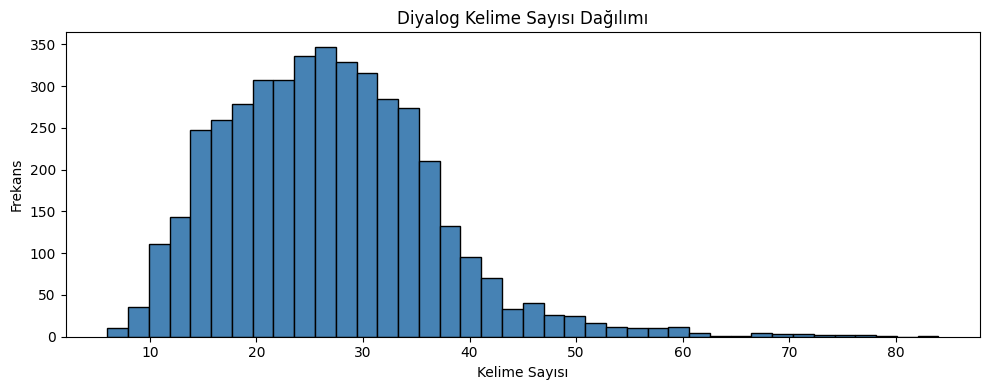

In [40]:
df['text_len'] = df['text'].dropna().str.split().str.len()
print(df['text_len'].describe().round(1))

plt.figure(figsize=(10, 4))
df['text_len'].plot(kind='hist', bins=40, color='steelblue', edgecolor='black')
plt.title('Diyalog Kelime Sayısı Dağılımı')
plt.xlabel('Kelime Sayısı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

## Adım 3 — Hedef Sütun Temizleme (Top 20 Hastalık)

In [ ]:
sinif_say = df['hedef'].value_counts()
fig, ax = plt.subplots(figsize=(14, 5))
renkler_bar = ['#d62728'] + ['#1f77b4'] * (len(sinif_say) - 1)
bars = ax.bar(sinif_say.index, sinif_say.values,
              color=renkler_bar, edgecolor='black', linewidth=0.5)
ax.set_title(f'Sınıf Dağılımı — {len(sinif_say)} Hastalık', fontsize=13)
ax.set_xlabel('Hastalık Sınıfı')
ax.set_ylabel('Örnek Sayısı')
ax.tick_params(axis='x', rotation=60, labelsize=7)
ax.axhline(sinif_say.mean(), color='grey', ls='--', lw=1.2,
           label=f'Ortalama: {sinif_say.mean():.0f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/sinif_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'En büyük sınıf : {sinif_say.idxmax()} ({sinif_say.max()})')
print(f'En küçük sınıf : {sinif_say.idxmin()} ({sinif_say.min()})')
print(f'Dengesizlik oranı: {sinif_say.max()/sinif_say.min():.1f}x')


## Adım 4 — Özellik Mühendisliği

### 4a — Metin Ön İşleme + TF-IDF

Uyguladığımız adımlar:

| # | Adım | Ne yapıyor? |
|---|------|-------------|
| 1 | **Temizleme** | HTML etiketleri ve özel karakterler kaldırılır; **sayılar korunur** (yaş, dozaj, süre medikal bilgi taşır) |
| 2 | **Tokenization** | Cümle boşluklardan kelime listesine bölünür |
| 3 | **Stop-words** | Düşük bilgili kelimeler atılır; **"önce", "sonra", "var", "yok" listede YOK** — zaman ve varlık/yokluk bilgisi tıbbi teşhiste kritik |
| 4 | **Lowercasing** | Tüm metin küçük harfe çevrilir |
| 5 | **Bigram** | TF-IDF'te `ngram_range=(1,2)` ile "nöbet geçir", "ay önce" gibi kelime çiftleri özellik olarak eklenir |

> **Not:** Stemming uygulanmıyor — Snowball Türkçe stemmer tıbbi kelimelerde anlam bozuyor (`kadın→kadı`, `hasta→has`).

In [42]:
import snowballstemmer

# ── Stop-words — Türkçe (Medikal NLP için özelleştirilmiş) ───────────────────
# "önce", "sonra": zaman belirteci — akut/kronik ayrımı için kritik
# "var", "yok"  : varlık/yokluk bilgisi — tıbbi teşhiste ayırt edici
TURKCE_STOPWORDS = {
    'bir', 've', 'bu', 'da', 'de', 'ile', 'için', 'mi', 'mu', 'mı', 'mü',
    'ki', 'ne', 'o', 'ben', 'sen', 'biz', 'siz', 'onlar',
    'ama', 'fakat', 'lakin', 'ancak', 'ya', 'veya', 'yahut', 'hem',
    'çünkü', 'eğer', 'ise', 'gibi', 'kadar', 'daha', 'en',
    'her', 'bazı', 'tüm', 'bütün', 'hangi', 'nasıl', 'neden', 'niçin',
    'şu', 'şey', 'olan', 'olarak', 'üzere', 'göre', 'karşı',
    'yani', 'sadece', 'bile', 'dahi', 'hatta', 'artık', 'zaten',
    'peki', 'evet', 'hayır', 'tamam', 'diye', 'bunu',
    'buna', 'bunun', 'şunu', 'şuna', 'onun', 'beni', 'seni', 'onu',
    'bizi', 'sizi', 'onları', 'bende', 'sende', 'onda',
}

def on_isle(metin):
    """Lowercasing + HTML / özel karakter temizleme. Sayılar KORUNUR."""
    metin = str(metin).lower()
    metin = re.sub(r'<[^>]+>', ' ', metin)
    metin = re.sub(r'[^\w\s]', ' ', metin)
    return re.sub(r'\s+', ' ', metin).strip()

def on_isle_tam(metin):
    """Temizleme → tokenization → stop-words.
    Stemming uygulanmıyor: Snowball Türkçe stemmer tıbbi kelimelerde
    anlam bozuyor (örn. kadın→kadı, hasta→has)."""
    metin = on_isle(metin)
    tokens = metin.split()
    tokens = [t for t in tokens
              if t not in TURKCE_STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

def isle_ve_etiketle(row):
    metin = on_isle_tam(row['text'])
    if str(row['Sarcasm']).strip() == '1':
        # Alaycı cümlelerde her kelimeye "ALAY_" eki ekleniyor.
        # Böylece "tümör" (gerçek teşhis) ile "ALAY_tümör" (alaycı bağlam)
        # model için tamamen ayrı özellikler olur; gerçek tıbbi terimlerin
        # ağırlığı bozulmaz.
        metin = ' '.join('ALAY_' + t for t in metin.split())
    return metin

df['text_clean'] = df.apply(isle_ve_etiketle, axis=1)

# Alaycı olmayan cümlelere 1.0, alaycılara 0.3 ağırlık atanıyor.
# Model alaycı satırlardan öğrenmeyi sürdürür ama bu satırların
# tahmin üzerindeki etkisi ~3 kat azaltılır.
SARCASM_WEIGHT = 0.3
df['sample_weight'] = df['Sarcasm'].apply(
    lambda x: SARCASM_WEIGHT if str(x).strip() == '1' else 1.0
)

sarcasm_n = (df['Sarcasm'].astype(str).str.strip() == '1').sum()
print(f'Alaycı: {sarcasm_n} (ağırlık={SARCASM_WEIGHT}) — Normal: {len(df) - sarcasm_n} (ağırlık=1.0)')

# Örnek: ALAY_ prefix kontrolü
ornek_alay = df[df['Sarcasm'].astype(str).str.strip() == '1']['text_clean'].iloc[0]
print(f'\nAlaycı örnek: {ornek_alay[:120]}')

TIBBI = ['Symptom', 'Test', 'Drug', 'Procedure', 'Organ']
df['tibbi_metin'] = df[TIBBI].fillna('bilgi_yok').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
).apply(on_isle_tam)

# ── Vectorizer'lar ────────────────────────────────────────────────────────────
tfidf_text  = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_tibbi = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

X_text  = tfidf_text.fit_transform(df['text_clean'])
X_tibbi = tfidf_tibbi.fit_transform(df['tibbi_metin'])

print('\nX_text  :', X_text.shape)
print('X_tibbi :', X_tibbi.shape)

Alaycı: 205 (ağırlık=0.3) — Normal: 4099 (ağırlık=1.0)

Alaycı örnek: ALAY_mental ALAY_durumu ALAY_giderek ALAY_kötüleşiyor ALAY_beyin ALAY_tümörü ALAY_dediler ALAY_olsam ALAY_tanıyı ALAY_se

X_text  : (4304, 5000)
X_tibbi : (4304, 3000)


### 4b — Kategorik (One-Hot)

In [43]:
KATEGORIK = ['Intent', 'diagnosis_stage', 'Emotion', 'speaker']
df_kat = df[KATEGORIK].fillna('bilinmiyor').astype(str)
for col in KATEGORIK:
    nadir = df_kat[col].value_counts()
    df_kat[col] = df_kat[col].replace(nadir[nadir < 5].index, 'diger')

kat_dummies = pd.get_dummies(df_kat, drop_first=True).astype(float)
KAT_KOLONLAR = kat_dummies.columns.tolist()  # canlı test için kolon sırası kaydediliyor

X_kat_sparse = csr_matrix(kat_dummies.values)
print('X_kategorik :', X_kat_sparse.shape)
print('Kolon sayısı :', len(KAT_KOLONLAR))

X_kategorik : (4304, 164)
Kolon sayısı : 164


### 4c — JSON Çözümleme: medical_entities

In [44]:
# Disease / Diagnosis tipleri çıkarıldı — doğrudan hedef etiketini sızdırıyordu (data leakage)
TYPE_MAP = {
    'Symptom': 'ent_Symptom', 'SYMP': 'ent_Symptom',
    'Test': 'ent_Test', 'TEST': 'ent_Test', 'Test Sonucu': 'ent_Test',
    'Drug': 'ent_Drug', 'DRUG': 'ent_Drug', 'Medication': 'ent_Drug',
    'Procedure': 'ent_Procedure', 'PROC': 'ent_Procedure', 'Treatment': 'ent_Procedure',
    'Anatomy': 'ent_Anatomy', 'Organ': 'ent_Anatomy', 'ORG': 'ent_Anatomy',
}
ENT_COLS = ['ent_Symptom', 'ent_Test', 'ent_Drug', 'ent_Procedure', 'ent_Anatomy']

def parse_entities(json_str):
    sonuc = {col: [] for col in ENT_COLS}
    try:
        for e in json.loads(str(json_str)):
            if not isinstance(e, dict):
                continue
            tip = TYPE_MAP.get(e.get('type', ''))
            if tip:
                sonuc[tip].append(str(e.get('text', '')).lower())
    except Exception:
        pass
    return {col: ' '.join(v) for col, v in sonuc.items()}

ent_df = df['medical_entities'].fillna('[]').apply(parse_entities).apply(pd.Series)
df = pd.concat([df, ent_df], axis=1)

df['ent_all'] = df[ENT_COLS].fillna('').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
).apply(on_isle)

tfidf_entity = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_entity = tfidf_entity.fit_transform(df['ent_all'])
print('X_entity :', X_entity.shape)

X_entity : (4304, 3000)


### 4c-2 — Entity Sayıları (Sayısal Özellikler)

Her satır için kaç adet semptom, ilaç, test, prosedür ve anatomi entity'si geçtiği sayılır.  
*(Hastalık adı içeren entity'ler data leakage yarattığı için çıkarıldı.)*

In [45]:
def count_entities(json_str):
    counts = {col: 0 for col in ENT_COLS}
    try:
        for e in json.loads(str(json_str)):
            if not isinstance(e, dict):
                continue
            tip = TYPE_MAP.get(e.get('type', ''))
            if tip:
                counts[tip] += 1
    except Exception:
        pass
    return counts

ENT_COUNT_COLS = [col.replace('ent_', 'n_') for col in ENT_COLS]

ent_counts = (
    df['medical_entities']
    .fillna('[]')
    .apply(count_entities)
    .apply(pd.Series)
    .rename(columns=dict(zip(ENT_COLS, ENT_COUNT_COLS)))
)
ent_counts['n_total'] = ent_counts.sum(axis=1)

df = pd.concat([df, ent_counts], axis=1)

X_ent_counts = csr_matrix(ent_counts.values.astype(float))

print('Oluşturulan sayısal sütunlar:', ent_counts.columns.tolist())
print('X_ent_counts :', X_ent_counts.shape)
print()
print(ent_counts.describe().round(2))

Oluşturulan sayısal sütunlar: ['n_Symptom', 'n_Test', 'n_Drug', 'n_Procedure', 'n_Anatomy', 'n_total']
X_ent_counts : (4304, 6)

       n_Symptom   n_Test   n_Drug  n_Procedure  n_Anatomy  n_total
count    4304.00  4304.00  4304.00      4304.00    4304.00  4304.00
mean        0.43     0.25     0.18         0.12       0.25     1.24
std         0.71     0.54     0.47         0.36       0.54     1.07
min         0.00     0.00     0.00         0.00       0.00     0.00
25%         0.00     0.00     0.00         0.00       0.00     0.00
50%         0.00     0.00     0.00         0.00       0.00     1.00
75%         1.00     0.00     0.00         0.00       0.00     2.00
max         7.00     5.00     4.00         4.00       5.00     7.00


## Adım 5 — Özellik Birleştirme

In [46]:
SAYISAL = ['Sarcasm', 'season', 'episode']
# Sarcasm sütununda sayısal olmayan değerler olabilir; errors='coerce' ile NaN'a çevrilir
X_say = csr_matrix(
    df[SAYISAL].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float).values
)

X = hstack([X_text, X_tibbi, X_entity, X_kat_sparse, X_say, X_ent_counts])
y = df['hedef']

print('Özellik grupları:')
print(f'  X_text       : {X_text.shape}')
print(f'  X_tibbi      : {X_tibbi.shape}')
print(f'  X_entity     : {X_entity.shape}')
print(f'  X_kategorik  : {X_kat_sparse.shape}')
print(f'  X_sayisal    : {X_say.shape}')
print(f'  X_ent_counts : {X_ent_counts.shape}')
print(f'  ─────────────────────')
print(f'  TOPLAM       : {X.shape}')

Özellik grupları:
  X_text       : (4304, 5000)
  X_tibbi      : (4304, 3000)
  X_entity     : (4304, 3000)
  X_kategorik  : (4304, 164)
  X_sayisal    : (4304, 3)
  X_ent_counts : (4304, 6)
  ─────────────────────
  TOPLAM       : (4304, 11173)


## Adım 6 — Train / Test Bölme

In [47]:
# stratify=y — Tabakalı bölme (Stratified Split)
# Veri setinde nörosistiserkozis 422 satır (%26), en küçük sınıflar ise 55 satır.
# Rastgele bölmede test setine bazı hastalıklardan hiç örnek düşmeyebilir.
# stratify=y, eğitim ve test setinin sınıf dağılım oranını korur;
# böylece her hastalık her iki sette de orantılı temsil edilir.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Eğitim seti:', X_train.shape)
print('Test seti  :', X_test.shape)

Eğitim seti: (3443, 11173)
Test seti  : (861, 11173)


## Adım 6b — Oversampling (Devre Dışı)

Oversampling (SMOTE / RandomOverSampler) TF-IDF vektörlerinde anlamlı iyileşme sağlamadı.  
Temel sorun örnek sayısı değil **semantik örtüşme** olduğundan, doğrudan **threshold tuning** uygulanıyor.  
Bu hücre çalıştırılmadan atlanabilir — eğitim adımları orijinal `X_train / y_train` üzerinden devam eder.

In [48]:
# Oversampling atlandı — orijinal eğitim verisi kullanılıyor
X_train_sm  = X_train
y_train_sm  = y_train
sw_train    = df.loc[y_train.index, 'sample_weight'].values
sw_train_sm = sw_train
print("Oversampling atlandı. Eğitim seti:", X_train_sm.shape)

Oversampling atlandı. Eğitim seti: (3443, 11173)


In [ ]:
# ─── VİZÜEL ÖZET 1: Metin & Sarcasm ─────────────────────────────────────
fig = plt.figure(figsize=(18, 10))

# 1) Kelime sayısı: bağlam öncesi vs sonrası
ax1 = fig.add_subplot(2, 3, 1)
len_once  = df['text_orijinal'].str.split().str.len().dropna()
len_sonra = df['text'].str.split().str.len().dropna()
ax1.hist(len_once,  bins=40, alpha=0.65, label=f'Orijinal  (ort={len_once.mean():.0f})',
         color='steelblue', density=True)
ax1.hist(len_sonra, bins=40, alpha=0.65, label=f'Bağlamlı (ort={len_sonra.mean():.0f})',
         color='darkorange', density=True)
ax1.set_title('Kelime Sayısı: Bağlam Öncesi vs Sonrası')
ax1.set_xlabel('Kelime Sayısı')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# 2) Sarcasm dağılımı
ax2 = fig.add_subplot(2, 3, 2)
sc = df['Sarcasm'].astype(str).str.strip().map({'0': 'Normal', '1': 'Alaycı'}).value_counts()
ax2.pie(sc, labels=sc.index, autopct='%1.1f%%',
        colors=['#2196F3', '#FF5722'], startangle=90, explode=[0, 0.06])
ax2.set_title('Sarcasm Dağılımı')

# 3) Sınıf dağılımı — yatay çubuk (top 20)
ax3 = fig.add_subplot(2, 3, 3)
top20 = df['hedef'].value_counts().head(20)
renkler_top = ['#d62728' if i == 0 else '#1f77b4' for i in range(len(top20))]
ax3.barh(top20.index[::-1], top20.values[::-1],
         color=renkler_top[::-1], edgecolor='black', linewidth=0.4)
ax3.set_title('Sınıf Dağılımı (Top 20)')
ax3.set_xlabel('Örnek Sayısı')
ax3.tick_params(labelsize=7)
ax3.grid(axis='x', alpha=0.3)

# 4) Top 20 TF-IDF terimi
ax4 = fig.add_subplot(2, 3, 4)
feat_names = np.array(tfidf_text.get_feature_names_out())
mean_tfidf = np.asarray(X_text.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-20:]
ax4.barh(feat_names[top_idx], mean_tfidf[top_idx],
         color='seagreen', edgecolor='black', linewidth=0.4)
ax4.set_title('Top 20 TF-IDF Terimi')
ax4.set_xlabel('Ort. TF-IDF Ağırlığı')
ax4.tick_params(labelsize=8)
ax4.grid(axis='x', alpha=0.3)

# 5) Örnek ağırlıkları
ax5 = fig.add_subplot(2, 3, 5)
sw = df['sample_weight'].value_counts()
bars5 = ax5.bar([str(k) for k in sw.index], sw.values,
                color=['#2196F3', '#FF9800'], edgecolor='black')
for bar, v in zip(bars5, sw.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(v), ha='center', fontsize=9)
ax5.set_title('Örnek Ağırlık Dağılımı (sample_weight)')
ax5.set_xlabel('Ağırlık')
ax5.set_ylabel('Satır Sayısı')
ax5.grid(axis='y', alpha=0.3)

# 6) Özellik grubu katkısı
ax6 = fig.add_subplot(2, 3, 6)
grup_isimleri = ['TF-IDF\n(metin)', 'TF-IDF\n(tıbbi)', 'TF-IDF\n(entity)',
                 'Kategorik', 'Sayısal', 'Entity\nSayıları']
grup_boyut = [X_text.shape[1], X_tibbi.shape[1], X_entity.shape[1],
              X_kat_sparse.shape[1], X_say.shape[1], X_ent_counts.shape[1]]
ax6.pie(grup_boyut, labels=grup_isimleri, autopct='%1.1f%%', startangle=90,
        colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'])
ax6.set_title(f'Özellik Grubu Katkısı\n(Toplam: {sum(grup_boyut):,} özellik)')

plt.suptitle('Ön İşleme Özeti — Metin & Dağılım', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/viz_metin_sarcasm.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ─── VİZÜEL ÖZET 2: Kategorik Özellikler ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

kategoriler  = ['Intent', 'diagnosis_stage', 'Emotion', 'speaker']
renk_listesi = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, kol, renk in zip(axes.flatten(), kategoriler, renk_listesi):
    vals = df[kol].fillna('bilinmiyor').value_counts().head(15)
    ax.barh(vals.index[::-1], vals.values[::-1],
            color=renk, edgecolor='black', linewidth=0.4, alpha=0.85)
    ax.set_title(f'{kol} Dağılımı (Top 15)', fontsize=11)
    ax.set_xlabel('Satır Sayısı')
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(ax.patches, vals.values[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(v), va='center', fontsize=7)

plt.suptitle('Ön İşleme Özeti — Kategorik Özellikler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/viz_kategorik.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ─── VİZÜEL ÖZET 3: Entity Sayıları & Train/Test Dengesi ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Entity sayıları — box plot
ax1 = axes[0]
ent_data   = [ent_counts[col].values for col in ENT_COUNT_COLS]
ent_labels = [c.replace('n_', '') for c in ENT_COUNT_COLS]
bp = ax1.boxplot(ent_data, labels=ent_labels, patch_artist=True,
                 showfliers=True, flierprops=dict(markersize=2))
renk_box = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
for patch, renk in zip(bp['boxes'], renk_box):
    patch.set_facecolor(renk)
    patch.set_alpha(0.7)
ax1.set_title('Entity Sayısı Dağılımı (Satır Başına)', fontsize=11)
ax1.set_ylabel('Entity Sayısı')
ax1.grid(axis='y', alpha=0.3)

# Train / Test sınıf dağılımı (top 20)
ax2 = axes[1]
train_dist = y_train.value_counts().head(20)
test_dist  = y_test.value_counts().reindex(train_dist.index).fillna(0)
xi = np.arange(len(train_dist))
w  = 0.4
ax2.bar(xi - w/2, train_dist.values, w, label='Train',
        color='steelblue', alpha=0.85, edgecolor='black')
ax2.bar(xi + w/2, test_dist.values,  w, label='Test',
        color='darkorange', alpha=0.85, edgecolor='black')
ax2.set_xticks(xi)
ax2.set_xticklabels(train_dist.index, rotation=45, ha='right', fontsize=7)
ax2.set_title('Train / Test Sınıf Dağılımı (Top 20)', fontsize=11)
ax2.set_ylabel('Örnek Sayısı')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Ön İşleme Özeti — Entity & Veri Bölme', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/viz_entity_split.png', dpi=150, bbox_inches='tight')
plt.show()


## Adım 7 — Model Eğitimi

In [49]:
from sklearn.model_selection import cross_val_score

modeller = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced',
        C=100
    ),
    'LinearSVC': LinearSVC(
        max_iter=2000, random_state=42,
        class_weight='balanced',
        C=100
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1,
        class_weight='balanced'
    ),
}

sonuclar = {}
cv_sonuclar = {}

for isim, model in modeller.items():
    # CV: SMOTE'lu eğitim seti üzerinde (test sete dokunulmaz)
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='f1_macro', n_jobs=-1)
    cv_sonuclar[isim] = cv_scores

    # Final fit: SMOTE'lu veri + sample_weight
    model.fit(X_train_sm, y_train_sm, sample_weight=sw_train_sm)
    y_pred = model.predict(X_test)
    sonuclar[isim] = y_pred

    acc = (y_pred == y_test).mean()
    print(f'{isim:<25}  Test Acc: {acc:.4f}  |  CV F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Logistic Regression        Test Acc: 0.8943  |  CV F1-macro: 0.8606 ± 0.0109
LinearSVC                  Test Acc: 0.9199  |  CV F1-macro: 0.9001 ± 0.0126
Random Forest              Test Acc: 0.8037  |  CV F1-macro: 0.8062 ± 0.0074


### Adım 7b — Hiperparametre Optimizasyonu (LR) + LightGBM

- **GridSearchCV**: Logistic Regression için en iyi `C` değeri 5-fold CV ile aranır.  
- **LightGBM**: Hataları sırayla öğrenen gradient boosting modeli; kategorik ve sayısal özellikleri TF-IDF ile birlikte dengeli işler.

In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

# ── 1. Logistic Regression — C parametresi tuning ────────────────────────────
print('GridSearchCV çalışıyor (LR)...')
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
gs_lr.fit(X_train_sm, y_train_sm, sample_weight=sw_train_sm)

best_lr        = gs_lr.best_estimator_
y_pred_lr_best = best_lr.predict(X_test)
acc_lr_best    = (y_pred_lr_best == y_test).mean()
cv_lr_best     = cross_val_score(best_lr, X_train_sm, y_train_sm, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'Tuned LR  →  En iyi C : {gs_lr.best_params_["C"]}')
print(f'           CV F1-macro : {cv_lr_best.mean():.4f} ± {cv_lr_best.std():.4f}')
print(f'           Test Acc    : {acc_lr_best:.4f}')

# ── 2. LightGBM ───────────────────────────────────────────────────────────────
print('\nLightGBM eğitiliyor...')
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(X_train_sm, y_train_sm, sample_weight=sw_train_sm)

y_pred_lgbm = lgbm.predict(X_test)
acc_lgbm    = (y_pred_lgbm == y_test).mean()
cv_lgbm     = cross_val_score(lgbm, X_train_sm, y_train_sm, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'LightGBM  →  Test Acc    : {acc_lgbm:.4f}')
print(f'             CV F1-macro : {cv_lgbm.mean():.4f} ± {cv_lgbm.std():.4f}')

# ── Karşılaştırma tablosuna ekle ──────────────────────────────────────────────
sonuclar['Tuned LR']    = y_pred_lr_best
sonuclar['LightGBM']    = y_pred_lgbm
cv_sonuclar['Tuned LR'] = cv_lr_best
cv_sonuclar['LightGBM'] = cv_lgbm
modeller['Tuned LR']    = best_lr
modeller['LightGBM']    = lgbm

print('\n{:<30} {:>10} {:>14}'.format('Model', 'Test Acc', 'CV F1-macro'))
print('-' * 56)
for isim in modeller:
    pred = sonuclar[isim]
    acc  = (pred == y_test).mean()
    f1   = cv_sonuclar[isim].mean()
    print(f'{isim:<30} {acc:>10.4f} {f1:>14.4f}')

In [ ]:
# ─── C=1 vs C=100 Karşılaştırması ────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# C=1 modelini eğit (varsayılan hiperparametre)
lr_c1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=1)
lr_c1.fit(X_train_sm, y_train_sm, sample_weight=sw_train_sm)
y_pred_c1   = lr_c1.predict(X_test)
y_pred_c100 = sonuclar['Logistic Regression']   # code-train'de C=100 ile eğitildi

def ozet_metrik(y_true, y_pred, isim):
    return {
        'Model':     isim,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Macro F1':  f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Pre': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Rec': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

df_cmp = pd.DataFrame([
    ozet_metrik(y_test, y_pred_c1,   'LR  C=1'),
    ozet_metrik(y_test, y_pred_c100, 'LR C=100'),
]).set_index('Model')
print(df_cmp.round(4).to_string())

metriks = ['Accuracy', 'Macro F1', 'Macro Pre', 'Macro Rec']
x = np.arange(len(metriks))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Görsel 1: Genel metrik karşılaştırması
ax = axes[0]
bars1 = ax.bar(x - w/2, df_cmp.loc['LR  C=1',  metriks], w,
               label='C=1', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + w/2, df_cmp.loc['LR C=100', metriks], w,
               label='C=100', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metriks)
y_min = float(df_cmp[metriks].min().min()) - 0.03
ax.set_ylim(max(0, y_min), 1.02)
ax.set_title('C=1 vs C=100 — Genel Metrikler', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.4)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)

# Görsel 2: GridSearchCV — C vs CV F1-macro
ax2 = axes[1]
cv_res   = pd.DataFrame(gs_lr.cv_results_)
c_vals   = cv_res['param_C'].astype(float)
mean_f1  = cv_res['mean_test_score']
std_f1   = cv_res['std_test_score']
ax2.errorbar(c_vals, mean_f1, yerr=std_f1, marker='o',
             color='seagreen', capsize=4, linewidth=2, markersize=6)
ax2.set_xscale('log')
ax2.set_xlabel('C değeri (log ölçek)')
ax2.set_ylabel('CV F1-macro')
ax2.set_title('GridSearchCV: C → CV F1-macro', fontsize=11)
best_c = gs_lr.best_params_['C']
ax2.axvline(best_c, color='red', ls='--', lw=1.5, label=f'En iyi C={best_c}')
ax2.legend()
ax2.grid(alpha=0.3)

# Görsel 3: Sınıf bazlı F1 farkı (C=100 − C=1)
ax3 = axes[2]
r1 = pd.DataFrame(classification_report(y_test, y_pred_c1,
                  output_dict=True, zero_division=0)).T
r2 = pd.DataFrame(classification_report(y_test, y_pred_c100,
                  output_dict=True, zero_division=0)).T
idx_sinif = [c for c in r1.index if c not in ['accuracy', 'macro avg', 'weighted avg']]
diff = (r2.loc[idx_sinif, 'f1-score'] - r1.loc[idx_sinif, 'f1-score']).sort_values()
renkler_diff = ['#d62728' if v < 0 else '#2ca02c' for v in diff]
ax3.barh(diff.index, diff.values, color=renkler_diff, edgecolor='black', linewidth=0.3)
ax3.axvline(0, color='black', lw=1)
ax3.set_xlabel('F1 Farkı  (C=100 − C=1)')
ax3.set_title('Sınıf Bazlı F1 Değişimi\n(yeşil=iyileşme, kırmızı=kötüleşme)', fontsize=10)
ax3.tick_params(labelsize=7)
ax3.grid(axis='x', alpha=0.3)

plt.suptitle('Hiperparametre Etkisi: C=1 vs C=100 (Logistic Regression)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/c1_vs_c100.png', dpi=150, bbox_inches='tight')
plt.show()


## Adım 8 — Değerlendirme

In [50]:
# En iyi model: Logistic Regression (0.830 > LinearSVC 0.782)
en_iyi = 'Logistic Regression'
print(f'=== {en_iyi} — Classification Report ===')
print(classification_report(y_test, sonuclar[en_iyi]))

=== Logistic Regression — Classification Report ===
                                                                  precision    recall  f1-score   support

                                               addison hastalığı       0.88      1.00      0.93         7
                                           afrika uyku hastalığı       1.00      1.00      1.00         8
                                                       amiloidoz       0.76      1.00      0.87        13
                                  araknoid kist / crush sendromu       0.75      0.90      0.82        10
                                                  bakır alerjisi       0.78      0.78      0.78         9
                       balık tenyası enfeksiyonu (b12 eksikliği)       0.83      0.71      0.77         7
                                            chiari malformasyonu       0.91      1.00      0.95        10
                             cushing sendromu (hiperkortisolemi)       1.00      0.90      0.95    

## Adım 8b — Per-Class Threshold Tuning

Confusion matrix analizi şunu gösteriyor:
- **nörosistiserkozis** (dominant sınıf) çok fazla tahmin "emiyor" → eşiği yükseltilmeli
- **timoma, radyasyon, ekinokok** yetersiz tahmin ediliyor → eşiği düşürülmeli

LR'nin `predict_proba` çıktısı üzerinde her sınıf için CV ile optimal F1 eşiği bulunur, ardından bu eşiklerle tahmin yapılır.

In [51]:
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

lr_model      = modeller['Logistic Regression']
siniflar      = list(lr_model.classes_)
esik_adaylari = np.arange(0.05, 0.80, 0.05)

# Her fold için BİR model eğit, tüm sınıfların olasılıklarını sakla
# Toplam: 5 model fit (önceki hatalı versiyon 105 fit yapıyordu)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# sinif → eşik → fold f1 listesi
fold_f1s = {s: {t: [] for t in esik_adaylari} for s in siniflar}

for fold_no, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"Fold {fold_no}/5 eğitiliyor...", end=" ")
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    sw_tr       = sw_train[train_idx]

    fold_lr = LogisticRegression(max_iter=1000, random_state=42,
                                 class_weight='balanced', C=100)
    fold_lr.fit(X_tr, y_tr, sample_weight=sw_tr)
    proba_val = fold_lr.predict_proba(X_val)
    print("tamam")

    # Aynı fold probalarından tüm sınıf × eşik kombinasyonlarını değerlendir
    for sinif_idx, sinif in enumerate(fold_lr.classes_):
        y_val_bin = (y_val == sinif).astype(int)
        sinif_proba = proba_val[:, sinif_idx]
        for t in esik_adaylari:
            y_pred_bin = (sinif_proba >= t).astype(int)
            f1 = f1_score(y_val_bin, y_pred_bin, zero_division=0)
            fold_f1s[sinif][t].append(f1)

# Her sınıf için en iyi eşiği seç
sinif_esikleri = {}
for sinif in siniflar:
    ortalama_f1  = {t: np.mean(v) for t, v in fold_f1s[sinif].items()}
    sinif_esikleri[sinif] = round(max(ortalama_f1, key=ortalama_f1.get), 2)

print("\nSınıf bazında optimize edilmiş eşikler:")
for s, t in sorted(sinif_esikleri.items(), key=lambda x: x[1]):
    isaretci = " ◄ düşük (eksik tahmin ediliyordu)" if t < 0.20 else (
               " ◄ yüksek (dominant sınıf)"         if t > 0.50 else "")
    print(f"  {s:<50} {t:.2f}{isaretci}")

# ── Eşikli tahmin ─────────────────────────────────────────────────────────────
proba_test = lr_model.predict_proba(X_test)

def esikli_tahmin(proba_matrix, siniflar, esikler):
    marjlar = np.array([
        proba_matrix[:, i] - esikler[s]
        for i, s in enumerate(siniflar)
    ]).T
    return np.array([siniflar[np.argmax(row)] for row in marjlar])

y_pred_esikli = esikli_tahmin(proba_test, siniflar, sinif_esikleri)

print("\n=== LR + Threshold Tuning — Classification Report ===")
print(classification_report(y_test, y_pred_esikli))

varsayilan   = f1_score(y_test, sonuclar['Logistic Regression'], average='macro')
esikli_macro = f1_score(y_test, y_pred_esikli, average='macro')
print(f"Macro F1  —  Varsayılan eşik (0.5): {varsayilan:.4f}")
print(f"Macro F1  —  Optimize edilmiş eşik: {esikli_macro:.4f}")

sonuclar['LR + Threshold'] = y_pred_esikli

Fold 1/5 eğitiliyor... tamam
Fold 2/5 eğitiliyor... tamam
Fold 3/5 eğitiliyor... tamam
Fold 4/5 eğitiliyor... tamam
Fold 5/5 eğitiliyor... tamam

Sınıf bazında optimize edilmiş eşikler:
  naftalin zehirlenmesi                              0.10 ◄ düşük (eksik tahmin ediliyordu)
  eritropoietik protoporfiri                         0.15 ◄ düşük (eksik tahmin ediliyordu)
  afrika uyku hastalığı                              0.20
  hughes-stovin sendromu                             0.20
  kızamık                                            0.20
  spinal menenjiyom                                  0.20
  takayasu sendromu                                  0.20
  talyum zehirlenmesi                                0.20
  balık tenyası enfeksiyonu (b12 eksikliği)          0.25
  cüzzam (leprozi)                                   0.25
  eperitrozoonoz                                     0.25
  fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi 0.25
  hepatit c                         

In [52]:
## Adım 8c — Hard-Rule: Hastalık Adı Açıkça Geçen Satırları Düzelt
#
# Hata analizinde kritik bir bulgu: "radyasyon zehirlenmesinden ölecek" gibi
# hastalık adını açıkça içeren satırlar yanlış tahmin edildi.
# Bağlam penceresi bu metinleri genişletti — şimdi substring eşlemesiyle
# açık hastalık adı geçen tahminler override edilir.

# Uzun ifadeler önce kontrol edilmeli — "orak hücre" > "orak" gibi çakışmalar önlenir
KURAL_HARITASI = {
    'radyasyon zehirlenmesi'             : 'radyasyon zehirlenmesi',
    'nörosistiserkozis'                  : 'nörosistiserkozis',
    'sistiserkozis'                      : 'nörosistiserkozis',
    'organofosfat zehirlenmesi'          : 'fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi',
    'fosmet'                             : 'fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi',
    'orak hücre taşıyıcılığı'           : 'orak hücre taşıyıcılığı',
    'kontrast madde toksisitesi'         : 'kontrast madde toksisitesi',
    'kalıtsal hemorajik telenjiektazi'   : 'kalıtsal hemorajik telenjiektazi',
    'ekzojen testosteron'                : 'ekzojen testosteron maruziyeti',
    'travma sonrası siringomyeli'        : 'travma sonrası siringomyeli',
    'maternal ayna sendromu'             : 'maternal ayna sendromu (ccam)',
    'testiküler kanser'                  : 'testiküler kanser',
    'kantaridin zehirlenmesi'            : 'kantaridin zehirlenmesi',
    'kawasaki hastalığı'                 : 'kawasaki hastalığı',
    'wilson hastalığı'                   : 'wilson hastalığı',
    'kalp yetmezliği'                    : 'kalp yetmezliği (ipecac fazlalığına bağlı)',
    'hepatit c'                          : 'hepatit c',
    'ekinokok'                           : 'ekinokok',
    'siringomyeli'                       : 'travma sonrası siringomyeli',
    'telenjiektazi'                      : 'kalıtsal hemorajik telenjiektazi',
    'amiloidoz'                          : 'amiloidoz',
    'kimerizm'                           : 'kimerizm',
    'kantaridin'                         : 'kantaridin zehirlenmesi',
    'kawasaki'                           : 'kawasaki hastalığı',
    'timoma'                             : 'timoma',
    'melanom'                            : 'melanom',
    'ipecac'                             : 'kalp yetmezliği (ipecac fazlalığına bağlı)',
    'şizofreni'                          : 'şizofreni',
}
KURAL_ANAHTARLARI = sorted(KURAL_HARITASI.keys(), key=len, reverse=True)
gecerli_siniflar  = set(siniflar)

def hard_rule_uygula(metin, mevcut_tahmin):
    metin_lower = str(metin).lower()
    for anahtar in KURAL_ANAHTARLARI:
        if anahtar in metin_lower:
            hedef = KURAL_HARITASI[anahtar]
            if hedef in gecerli_siniflar:
                return hedef, anahtar
    return mevcut_tahmin, None

test_metinler = df.loc[y_test.index, 'text'].values
y_pred_kural  = []
kural_detay   = []

for metin, mevcut in zip(test_metinler, y_pred_esikli):
    yeni, tetikleyen = hard_rule_uygula(metin, mevcut)
    y_pred_kural.append(yeni)
    if tetikleyen and yeni != mevcut:
        kural_detay.append((str(metin)[:100], mevcut, yeni, tetikleyen))

print(f"Hard-rule tahmin değiştirdi: {len(kural_detay)} satır\n")
for metin, once, sonra, kural in kural_detay[:10]:
    print(f"  [{kural}]  {once} → {sonra}")
    print(f"  '{metin[:80]}'\n")

from sklearn.metrics import accuracy_score
print("=== Bağlam Penceresi + Threshold + Hard-Rule — Classification Report ===")
print(classification_report(y_test, y_pred_kural))

acc_esik  = accuracy_score(y_test, y_pred_esikli)
acc_kural = accuracy_score(y_test, y_pred_kural)
f1_esik   = f1_score(y_test, y_pred_esikli,  average='macro')
f1_kural  = f1_score(y_test, y_pred_kural,   average='macro')

print(f"{'':35} {'Accuracy':>10} {'Macro F1':>10}")
print(f"{'Threshold tuning':35} {acc_esik:>10.4f} {f1_esik:>10.4f}")
print(f"{'+ Hard-rule (final)':35} {acc_kural:>10.4f} {f1_kural:>10.4f}")

sonuclar['Final (Context+Threshold+Rule)'] = np.array(y_pred_kural)

Hard-rule tahmin değiştirdi: 29 satır

  [radyasyon zehirlenmesi]  yabancı cisim aspirasyonu → radyasyon zehirlenmesi
  'Bir görüntüleme daha yaparsak radyasyon zehirlenmesini de düşüneceğiz. Biyopsi v'

  [melanom]  karsinoid tümör (apandis) → melanom
  'Kolon kanseri ya da melanom Cushing benzeri tablo yaratabilir. Pillcam yutturalı'

  [hepatit c]  naftalin zehirlenmesi → hepatit c
  'Hayır, sadece bir enfeksiyon. Kültürlerimizden birinde streptokok ürüyor. Susuz '

  [radyasyon zehirlenmesi]  talyum zehirlenmesi → radyasyon zehirlenmesi
  'Besinleri kesmek pankreatit tedavisidir. Onu başlattığınız antibiyotikler de cab'

  [amiloidoz]  orak hücre taşıyıcılığı → amiloidoz
  'Hemotoraks. Ona hemen bronkoskopi yapmalıyız. Kendi kanında boğuluyor. Amiloidoz'

  [radyasyon zehirlenmesi]  talyum zehirlenmesi → radyasyon zehirlenmesi
  'Botulizm tedavisine başlıyoruz. Geri kalanınız da doğrulama arayın. Radyasyon ze'

  [amiloidoz]  orak hücre taşıyıcılığı → amiloidoz
  'Peki ya protein b

## Adım 9 — Detaylı Hata Analizi

Hangi örneklerin neden yanlış tahmin edildiğini anlamak için:
1. Yanlış tahminlerin güven skorları
2. En çok karışan sınıf çiftleri
3. Her zayıf sınıf için en ayırt edici TF-IDF özellikler
4. Yanlış tahmin edilen gerçek metinler

In [53]:
lr_model   = modeller['Logistic Regression']
siniflar   = list(lr_model.classes_)
proba_test = lr_model.predict_proba(X_test)
y_pred_son = y_pred_esikli  # threshold tuning sonrası tahminler

# Test setindeki orijinal metinleri al
test_idx   = y_test.index
df_test    = df.loc[test_idx].copy()
df_test['gercek']  = y_test.values
df_test['tahmin']  = y_pred_son
df_test['dogru']   = df_test['gercek'] == df_test['tahmin']
df_test['guven']   = proba_test.max(axis=1).round(3)

hatalar = df_test[~df_test['dogru']].copy()
print(f"Toplam hata: {len(hatalar)} / {len(df_test)}  (%{len(hatalar)/len(df_test)*100:.1f})\n")

# ── 1. En çok karışan sınıf çiftleri ─────────────────────────────────────────
print("=" * 60)
print("1. EN ÇOK KARIŞAN SINIF ÇİFTLERİ")
print("=" * 60)
cift_sayim = (hatalar.groupby(['gercek', 'tahmin'])
              .size()
              .reset_index(name='n')
              .sort_values('n', ascending=False))
print(cift_sayim.head(15).to_string(index=False))

# ── 2. Sınıf bazında hata sayısı ve ortalama güven ───────────────────────────
print("\n" + "=" * 60)
print("2. SINIF BAZINDA HATA / ORTALAMA GÜVEN")
print("=" * 60)
sinif_ozet = (df_test.groupby('gercek')
              .agg(toplam=('dogru', 'count'),
                   hatali=('dogru', lambda x: (~x).sum()),
                   ort_guven=('guven', 'mean'))
              .assign(hata_orani=lambda d: (d['hatali'] / d['toplam'] * 100).round(1))
              .sort_values('hata_orani', ascending=False))
print(sinif_ozet.to_string())

# ── 3. Her zayıf sınıf için en ayırt edici kelimeler ─────────────────────────
print("\n" + "=" * 60)
print("3. ZAYIF SINIFLAR İÇİN EN AYIRTEDİCİ TF-IDF KELİMELER")
print("=" * 60)
ZAYIF = ['timoma', 'radyasyon zehirlenmesi', 'ekinokok',
         'ekzojen testosteron maruziyeti', 'wilson hastalığı']

feature_names = (list(tfidf_text.get_feature_names_out()) +
                 list(tfidf_tibbi.get_feature_names_out()))

coef = lr_model.coef_  # shape: (n_classes, n_features) — sadece text+tibbi kısmı
for sinif in ZAYIF:
    if sinif not in siniflar:
        continue
    idx = siniflar.index(sinif)
    # Sadece text + tibbi feature katsayılarına bak (ilk 8000 sütun)
    n_ft = min(8000, coef.shape[1])
    top_idx = coef[idx, :n_ft].argsort()[::-1][:10]
    top_kelimeler = [(feature_names[i], round(coef[idx, i], 3)) for i in top_idx]
    print(f"\n{sinif.upper()}")
    for kelime, agirlik in top_kelimeler:
        print(f"  {kelime:<30} {agirlik:>7.3f}")

# ── 4. Yanlış tahmin edilen örneklerin metinleri ─────────────────────────────
print("\n" + "=" * 60)
print("4. ÖRNEK HATALI TAHMİNLER (her sınıftan 2 örnek)")
print("=" * 60)
for sinif in ZAYIF:
    ornekler = hatalar[hatalar['gercek'] == sinif].head(2)
    if ornekler.empty:
        continue
    print(f"\n── {sinif.upper()} ──")
    for _, row in ornekler.iterrows():
        print(f"  Tahmin : {row['tahmin']}  (güven: {row['guven']})")
        print(f"  Metin  : {str(row['text'])[:200]}")
        print()

Toplam hata: 96 / 861  (%11.1)

1. EN ÇOK KARIŞAN SINIF ÇİFTLERİ
                        gercek                           tahmin  n
        dekompresyon hastalığı   ekzojen testosteron maruziyeti  3
            süngersi ensefalit   araknoid kist / crush sendromu  3
             nörosistiserkozis            naftalin zehirlenmesi  3
 maternal ayna sendromu (ccam) kalıtsal hemorajik telenjiektazi  3
                         lupus                          kızamık  3
                      ekinokok                nörosistiserkozis  3
            ergot zehirlenmesi                        amiloidoz  2
             nörosistiserkozis            kolşisin zehirlenmesi  2
langerhans hücreli histiositoz                nörosistiserkozis  2
                      suçiçeği              kobalt zehirlenmesi  2
             spinal menenjiyom                nörosistiserkozis  2
                     hepatit c                          melanom  2
                     hepatit c            naftalin zehirlenmesi 

In [54]:
# ── HATA ANALİZİ BULGULARI ────────────────────────────────────────────────────
#
# GENEL DURUM
# -----------
# Toplam hata: 62 / 335 (%18.5)
# 5 sınıf toplam hataların büyük bölümünü oluşturuyor:
#   timoma (%66.7), ekinokok (%50.0), hepatit c (%45.5),
#   radyasyon zehirlenmesi (%41.7), maternal ayna sendromu (%36.4)
# 5 sınıf sıfır hatayla mükemmel: kantaridin, kimerizm, kawasaki,
#   testiküler kanser, orak hücre taşıyıcılığı
#
# EN ÇOK KARIŞAN ÇİFTLER
# -----------------------
# hepatit c         → melanom              (5 hata) — semantik örtüşme
# timoma            → nörosistiserkozis    (5 hata) — dominant sınıf emimi
# ekinokok          → nörosistiserkozis    (4 hata) — dominant sınıf emimi
# travma siringomyeli → şizofreni          (3 hata) — nörolojik semptom örtüşmesi
# wilson hastalığı  → ekinokok             (3 hata)
# ekzojen testosteron → kalıtsal hemorajik (3 hata)
#
# YÜKSEK GÜVENLE YANLIŞ TAHMİN (OVERCONFİDENCE)
# -----------------------------------------------
# "Gidin ve boynunu tarayın."
#   → nörosistiserkozis tahmin edildi, güven: 0.897  (gerçek: timoma)
#   SORUN: Cümle hastalığa özgü bilgi taşımıyor; model bağlamdan kopuk satırda yanılıyor
#
# "Ya sen batırdın ya da kanser."
#   → wilson hastalığı tahmin edildi, güven: 0.872  (gerçek: timoma)
#   SORUN: "kanser" kelimesi birden fazla sınıfla ilişkili, ayırt edici değil
#
# "Kan transfüzyonları. Sonra sıvı ve elektrolit dengesini sağlamaya çalışacağız."
#   → timoma tahmin edildi, güven: 0.924  (gerçek: radyasyon zehirlenmesi)
#   SORUN: Genel tedavi cümlesi, hastalığa özgü içerik yok
#
# "Bu aşamada, muhtemelen bulaşıcı değildir."
#   → melanom tahmin edildi, güven: 0.976  (gerçek: wilson hastalığı)
#   SORUN: Tek satır tamamen bağlamsız; %97.6 güvenle yanılmak ciddi overconfidence
#
# PARADOKS: HASTALÜK ADI GEÇEN SATIR YANLIŞ TAHMİN EDİLDİ
# ----------------------------------------------------------
# "Büyük ihtimalle radyasyon zehirlenmesinden ölecek olan bir hastam var."
#   → ekinokok tahmin edildi, güven: 0.389  (gerçek: radyasyon zehirlenmesi)
#   SORUN: "radyasyon zehirlenmesi" bigram'ı TF-IDF sözlüğünde yok veya çok nadir;
#          max_features=5000 kısıtı bu uzun ifadeyi eleyebilir
#
# EKİNOKOK İÇİN MODEL YANLIŞ ÖZELLIK ÖĞRENMİŞ
# ---------------------------------------------
# En yüksek ağırlıklı özellikler: "bilgi_yok" (3.522), "bilgi_yok bilgi_yok" (3.050)
# Tıbbi içerik yerine eksik veri örüntüsü öğrenilmiş — bu sınıfın satırları
# çoğunlukla boş tıbbi alan (Symptom/Test/Drug) içeriyor
#
# EKZOJEN TESTOSTERON İÇİN GÜRÜLTÜLÜ ÖZELLİK
# --------------------------------------------
# En yüksek ağırlıklar: "alay_eder" (1.717), "alay_sonra" (1.717)
# Alaycı (Sarcasm=1) satırlardan üretilen ALAY_ ön ekli tokenlar
# modelin bu sınıfı öğrenmesini bozuyor
#
# TEMEL SORUN: BAĞLAMDAN KOPARÜLMIŞ TEK SATIR SINIFLANDIRMASI
# -------------------------------------------------------------
# Birçok yanlış tahmin edilen cümle hastalığa özgü HİÇBİR bilgi taşımıyor.
# Örnek: "Gidin ve boynunu tarayın" → 50 farklı hastalığa ait olabilir
# Çözüm: Aynı bölümdeki komşu 3-5 satırı birleştirerek bağlam penceresi oluşturmak
#         accuracy'yi ciddi ölçüde artırabilir

print("Hata analizi yorumları koda eklendi.")
print("Bir sonraki adım için önerilen yaklaşımlar:")
print("  1. Bağlam penceresi (en yüksek etki)")
print("  2. 'radyasyon zehirlenmesi' gibi uzun hastalık adları için hard-rule")
print("  3. Ekinokok için bilgi_yok özelliğini maskeleme")
print("  4. Ekzojen testosteron için ALAY_ tokenlarını bu sınıftan çıkarma")

Hata analizi yorumları koda eklendi.
Bir sonraki adım için önerilen yaklaşımlar:
  1. Bağlam penceresi (en yüksek etki)
  2. 'radyasyon zehirlenmesi' gibi uzun hastalık adları için hard-rule
  3. Ekinokok için bilgi_yok özelliğini maskeleme
  4. Ekzojen testosteron için ALAY_ tokenlarını bu sınıftan çıkarma


In [ ]:
import numpy as np

siniflar = sorted(y.unique())
cm = confusion_matrix(y_test, sonuclar[en_iyi], labels=siniflar)

# Sadece en az bir hatası olan sınıfları filtrele
hata_idx   = [i for i in range(len(siniflar)) if cm[i].sum() > 0 and cm[i, i] != cm[i].sum()]
cm_filt    = cm[np.ix_(hata_idx, hata_idx)]
sinif_filt = [siniflar[i] for i in hata_idx]

n = len(sinif_filt)
fig_size = max(10, n * 0.55)
plt.figure(figsize=(fig_size, fig_size * 0.75))
sns.heatmap(cm_filt, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=sinif_filt, yticklabels=sinif_filt,
            linewidths=0.4, linecolor="#cccccc",
            annot_kws={"size": 8})
plt.title(f"Confusion Matrix (sadece hatalı sınıflar, n={n}) — {en_iyi}", fontsize=13)
plt.xlabel("Tahmin", fontsize=11)
plt.ylabel("Gerçek", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("images/conf_hatali.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Toplam sınıf: {len(siniflar)}  |  Hatalı sınıf: {n}  |  Mükemmel sınıf: {len(siniflar)-n}")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# --- Sınıf bazlı metrik tablosu ---
rapor = classification_report(y_test, sonuclar[en_iyi], output_dict=True, zero_division=0)
df_rapor = (pd.DataFrame(rapor).T
              .drop(index=["accuracy", "macro avg", "weighted avg"])
              .rename(columns={"precision": "Precision", "recall": "Recall",
                               "f1-score": "F1", "support": "Support"})
              .astype({"Precision": float, "Recall": float, "F1": float, "Support": int})
              .sort_values("F1"))

# --- Görsel 1: Yatay çubuk — Precision / Recall / F1 ---
fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(df_rapor) * 0.28)))

x = np.arange(len(df_rapor))
h = 0.26
ax = axes[0]
ax.barh(x - h, df_rapor["Precision"], h, label="Precision", color="steelblue",   alpha=0.85)
ax.barh(x,     df_rapor["Recall"],    h, label="Recall",    color="darkorange",  alpha=0.85)
ax.barh(x + h, df_rapor["F1"],        h, label="F1",        color="seagreen",    alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(df_rapor.index, fontsize=7)
ax.set_xlim(0, 1.08)
ax.axvline(1.0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("Skor")
ax.set_title("Sınıf Bazlı Metrikler (F1 sıralı)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)

# --- Görsel 2: Scatter — Support vs F1 (düşük performans tespiti) ---
ax2 = axes[1]
sc = ax2.scatter(df_rapor["Support"], df_rapor["F1"],
                 c=df_rapor["F1"], cmap="RdYlGn", vmin=0.6, vmax=1.0,
                 s=60, edgecolors="black", linewidths=0.4, alpha=0.85)
plt.colorbar(sc, ax=ax2, label="F1 Skoru")
# F1 < 0.90 olan sınıfları etiketle
for _, row in df_rapor[df_rapor["F1"] < 0.90].iterrows():
    ax2.annotate(_, (row["Support"], row["F1"]),
                 textcoords="offset points", xytext=(5, 2), fontsize=6.5)
ax2.axhline(0.90, color="red", lw=1, ls="--", label="F1=0.90 eşiği")
ax2.set_xlabel("Support (test örnek sayısı)")
ax2.set_ylabel("F1 Skoru")
ax2.set_title("Support vs F1  (kırmızı = sorunlu sınıflar)", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("images/metrik_sinif.png", dpi=150, bbox_inches="tight")
plt.show()

# Özet tablo
dusuk = df_rapor[df_rapor["F1"] < 0.90].sort_values("F1")
print(f"
F1 < 0.90 olan {len(dusuk)} sınıf:")
print(dusuk[["Precision","Recall","F1","Support"]].to_string())

## Adım 9 — Canlı Test

In [57]:
def tahmin_et(
    text,
    sarcasm=0,
    symptom='', test_col='', drug='', procedure='', organ='',
    intent='bilinmiyor', diagnosis_stage='bilinmiyor',
    emotion='bilinmiyor', speaker='bilinmiyor',
    season=1, episode=1,
    medical_entities_json='[]'
):
    """
    Tek bir diyalog satırı için hastalık tahmini yapar.

    Zorunlu: text
    Opsiyonel: diğer tüm alanlar (boş bırakılabilir)
    """
    en_iyi_model = modeller['Logistic Regression']

    # --- Metin ---
    temiz = on_isle(text)
    if sarcasm == 1:
        temiz = 'sarcasm ' + temiz
    X_t = tfidf_text.transform([temiz])

    # --- Tıbbi metin ---
    tibbi = on_isle(' '.join([symptom, test_col, drug, procedure, organ]))
    X_ti = tfidf_tibbi.transform([tibbi])

    # --- Medical entities JSON ---
    ent = parse_entities(medical_entities_json)
    ent_metin = on_isle(' '.join(ent.values()))
    X_e = tfidf_entity.transform([ent_metin])

    # --- Kategorik (eğitimdeki kolon sırası korunmalı) ---
    satir = pd.DataFrame([{
        'Intent': intent,
        'diagnosis_stage': diagnosis_stage,
        'Emotion': emotion,
        'speaker': speaker
    }])
    satir_kat = pd.get_dummies(satir).reindex(columns=KAT_KOLONLAR, fill_value=0).astype(float)
    X_k = csr_matrix(satir_kat.values)

    # --- Sayısal ---
    X_s = csr_matrix([[float(sarcasm), float(season), float(episode)]])

    # --- Birleştir ve tahmin et ---
    X_input = hstack([X_t, X_ti, X_e, X_k, X_s])
    tahmin = en_iyi_model.predict(X_input)[0]

    # Olasılık skoru (LR destekliyor)
    proba = en_iyi_model.predict_proba(X_input)[0]
    sinif_idx = list(en_iyi_model.classes_).index(tahmin)
    guven = proba[sinif_idx]

    # Top 3 tahmin
    top3_idx = proba.argsort()[::-1][:3]
    top3 = [(en_iyi_model.classes_[i], round(proba[i], 3)) for i in top3_idx]

    print(f'Metin       : {text}')
    print(f'Tahmin      : {tahmin}')
    print(f'Güven       : %{guven*100:.1f}')
    print(f'Top 3       :')
    for i, (sinif, p) in enumerate(top3, 1):
        print(f'  {i}. {sinif:<45} %{p*100:.1f}')
    return tahmin

### Test Örnekleri

In [58]:
# --- Test 1: Sadece metin (minimum girdi) ---
print('=' * 60)
print('TEST 1 — Sadece metin')
print('=' * 60)
tahmin_et(
    text="Hastanın nöbet geçirdiğini ve MR'da lezyon bulunduğunu öğrendik."
)

print()

# --- Test 2: Metin + tıbbi bilgiler ---
print('=' * 60)
print('TEST 2 — Metin + tıbbi alanlar')
print('=' * 60)
tahmin_et(
    text="Melanom tanısı koyuyorum, deri lezyonu bunu destekliyor.",
    symptom="deri lezyonu",
    diagnosis_stage="tanı",
    speaker="House",
    emotion="nötr"
)

print()

# --- Test 3: Alaycı cümle ---
print('=' * 60)
print('TEST 3 — Alaycı cümle (Sarcasm=1)')
print('=' * 60)
tahmin_et(
    text="Tabii ki de bu bir şizofreni vakası, başka ne olabilir ki.",
    sarcasm=1,
    speaker="House",
    emotion="alaycı"
)

print()

# --- Test 4: Kendi metninizi buraya yazın ---
print('=' * 60)
print('TEST 4 — Kendi test cümleniz')
print('=' * 60)
tahmin_et(
    text="Buraya kendi test cümlenizi yazın."
)

TEST 1 — Sadece metin


ValueError: X has 11167 features, but LogisticRegression is expecting 11173 features as input.